# Proje Amacı

Bu projenin temel amacı, bir telekomünikasyon şirketindeki müşteri hareketlerini analiz ederek, hangi müşterilerin hizmeti iptal etme (Churn) eğiliminde olduğunu önceden yüksek doğrulukla tahmin etmektir.

**📊 Kaggle Playground S6E3: Veri Sözlüğü**

| Değişken Adı | Veri Tipi | Açıklama |
| :--- | :--- | :--- |
| **id** | int64 | Her bir müşteri için benzersiz tanımlayıcı. |
| **gender** | object | Müşterinin cinsiyeti (Male/Female). |
| **SeniorCitizen** | int64 | Müşterinin yaşlı olup olmadığı (1: Evet, 0: Hayır). |
| **Partner** | object | Müşterinin bir eşi/partneri olup olmadığı (Yes/No). |
| **Dependents** | object | Müşterinin bakmakla yükümlü olduğu kişiler olup olmadığı (Yes/No). |
| **tenure** | int64 | Müşterinin şirkette kaldığı ay sayısı. |
| **PhoneService** | object | Müşterinin telefon hizmeti olup olmadığı (Yes/No). |
| **MultipleLines** | object | Birden fazla telefon hattı olup olmadığı (Yes, No, No phone service). |
| **InternetService** | object | İnternet servis sağlayıcısı türü (DSL, Fiber optic, No). |
| **OnlineSecurity** | object | Çevrimiçi güvenlik hizmeti olup olmadığı (Yes, No, No internet service). |
| **OnlineBackup** | object | Çevrimiçi yedekleme hizmeti olup olmadığı (Yes, No, No internet service). |
| **DeviceProtection** | object | Cihaz koruma sigortası olup olmadığı (Yes, No, No internet service). |
| **TechSupport** | object | Teknik destek hizmeti alıp almadığı (Yes, No, No internet service). |
| **StreamingTV** | object | TV yayını hizmeti olup olmadığı (Yes, No, No internet service). |
| **StreamingMovies**| object | Film yayını hizmeti olup olmadığı (Yes, No, No internet service). |
| **Contract** | object | Müşterinin sözleşme süresi (Month-to-month, One year, Two year). |
| **PaperlessBilling**| object | Kağıtsız fatura (e-fatura) kullanıp kullanmadığı (Yes/No). |
| **PaymentMethod** | object | Ödeme yöntemi (Electronic check, Mailed check, Bank transfer, Credit card). |
| **MonthlyCharges** | float64 | Müşteriden her ay tahsil edilen tutar. |
| **TotalCharges** | float64 | Müşteriden şimdiye kadar tahsil edilen toplam tutar. |
| **Churn** | object | **Hedef Değişken:** Müşterinin ayrılıp ayrılmadığı (Yes/No). |

In [1]:
# pandas → veri okuma, düzenleme ve tablo (DataFrame) işlemleri için kullanılır
import pandas as pd

# numpy → sayısal işlemler ve matematiksel hesaplamalar için kullanılır
import numpy as np

# warnings → gereksiz uyarıları gizlemek için kullanılır
import warnings
warnings.filterwarnings('ignore')

# matplotlib → grafik çizmek için temel kütüphane
import matplotlib.pyplot as plt

# seaborn → daha estetik ve gelişmiş veri görselleştirme kütüphanesi
import seaborn as sns

#en yakın komşuya göre boş verileri doldurma
from sklearn.impute import KNNImputer

In [2]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')

In [3]:
#ilk 5 satırı göster
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:
#son 5 satırı göster
train.tail()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No
594193,594193,Female,1,Yes,No,2,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,54.55,108.05,Yes


In [5]:
#veriler hakkında bilgi
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [6]:
#boş veri kontrolü
train.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# sayısal veriler arası istatistik
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,594194.0,297096.500000,171529.177262,0.00,148548.25,297096.50,445644.75,594193.00
SeniorCitizen,594194.0,0.114102,0.317936,0.00,0.00,0.00,0.00,1.00
tenure,594194.0,36.577258,25.061922,1.00,12.00,35.00,62.00,72.00
MonthlyCharges,594194.0,65.866223,31.067444,18.25,29.90,74.10,90.80,118.75
TotalCharges,594194.0,2494.377057,2353.916710,18.80,639.65,1433.65,4263.80,8684.80


In [8]:
#sayısal veriler arası korelasyon
train.corr(numeric_only=True)

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
id,1.000000,0.002035,0.019322,0.005729,0.014331
SeniorCitizen,0.002035,1.000000,-0.084291,0.229079,0.042786
tenure,0.019322,-0.084291,1.000000,0.124043,0.769703
MonthlyCharges,0.005729,0.229079,0.124043,1.000000,0.634237
TotalCharges,0.014331,0.042786,0.769703,0.634237,1.000000


In [9]:
train['InternetService'].value_counts()

InternetService
Fiber optic    272386
DSL            181081
No             140727
Name: count, dtype: int64

In [10]:
train['Contract'].value_counts()

Contract
Month-to-month    298918
Two year          186943
One year          108333
Name: count, dtype: int64

In [11]:
train['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             215372
Credit card (automatic)      133705
Mailed check                 123757
Bank transfer (automatic)    121360
Name: count, dtype: int64

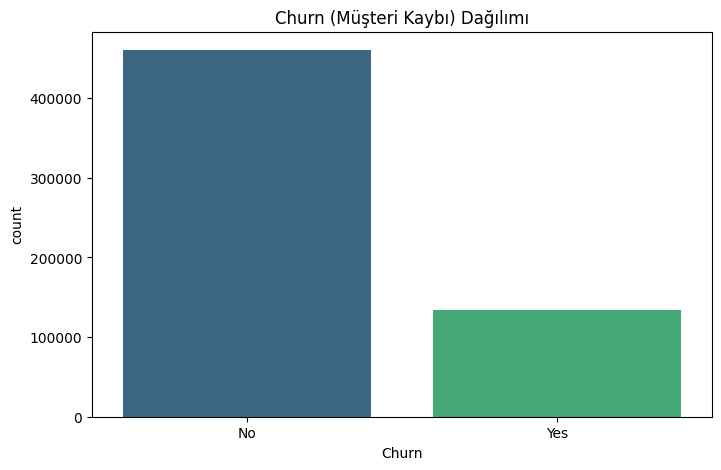

Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64


In [12]:
# Hedef değişkenin dağılımını görselleştirme
plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', data=train, palette='viridis')
plt.title('Churn (Müşteri Kaybı) Dağılımı')
plt.show()

# Oranları görelim
print(train['Churn'].value_counts(normalize=True))

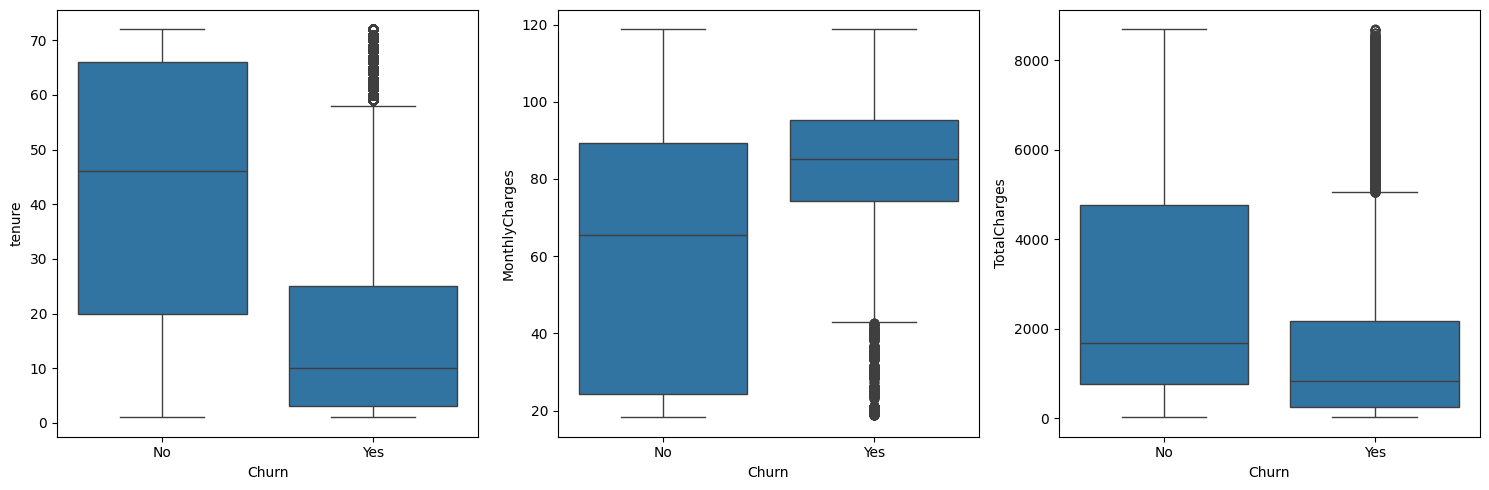

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x='Churn', y='tenure', data=train, ax=axes[0])
sns.boxplot(x='Churn', y='MonthlyCharges', data=train, ax=axes[1])
sns.boxplot(x='Churn', y='TotalCharges', data=train, ax=axes[2])

plt.tight_layout()
plt.show()

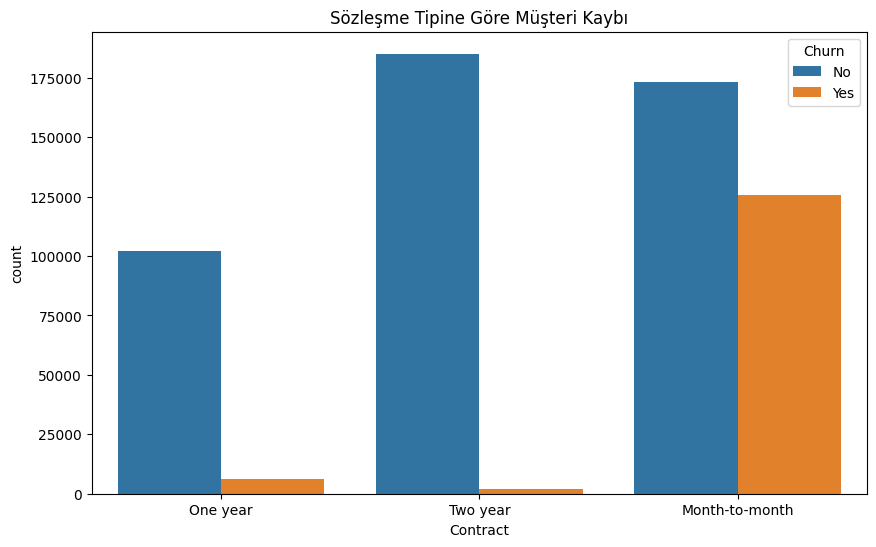

In [14]:
# Sözleşme tipine göre Churn durumu
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=train)
plt.title('Sözleşme Tipine Göre Müşteri Kaybı')
plt.show()

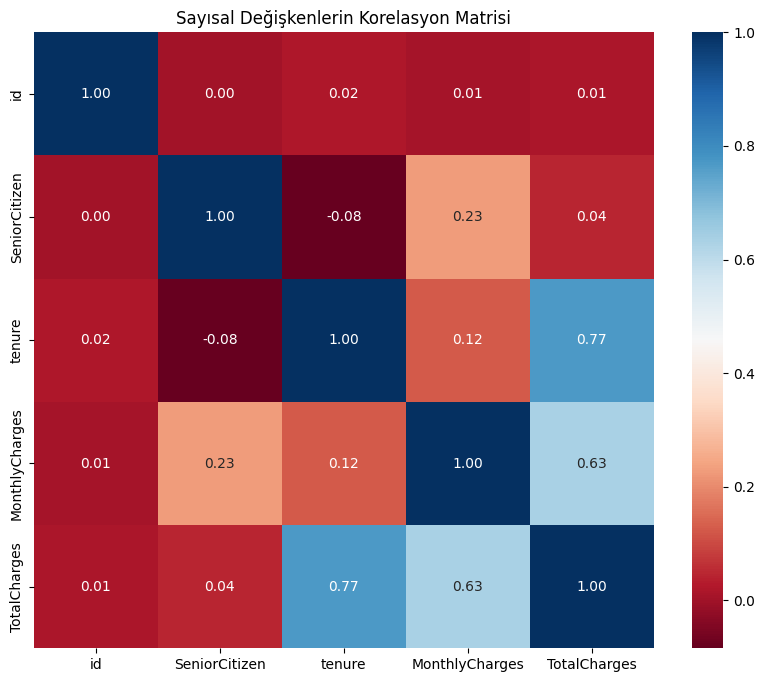

In [15]:
# Sadece sayısal sütunları seçelim
numeric_cols =train.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(10, 8))
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='RdBu', fmt=".2f")
plt.title('Sayısal Değişkenlerin Korelasyon Matrisi')
plt.show()

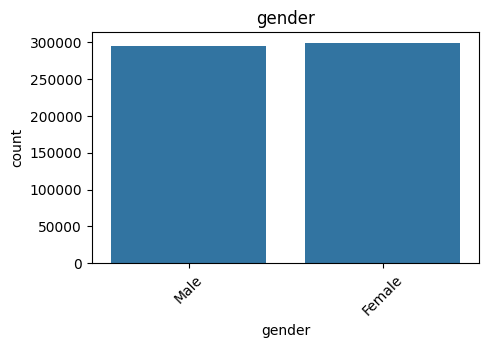

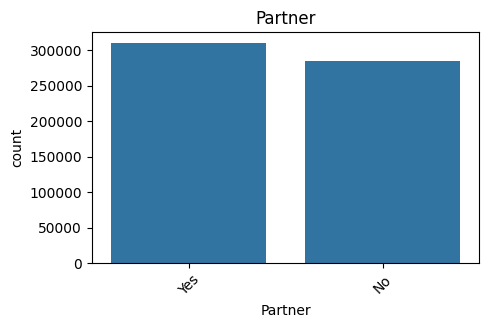

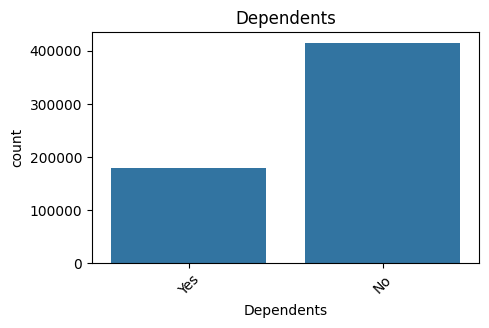

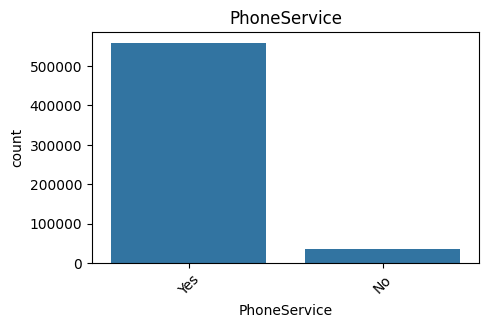

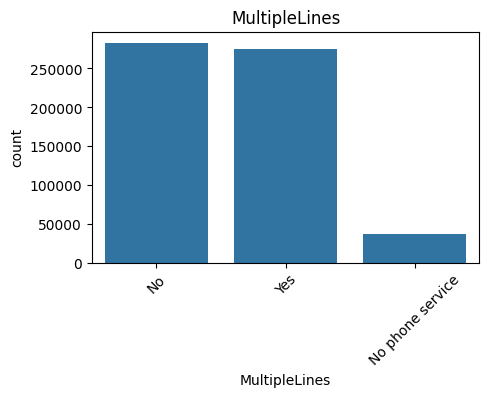

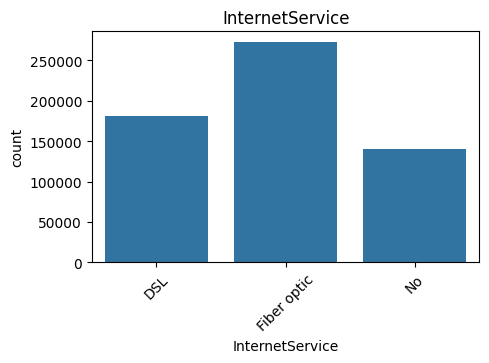

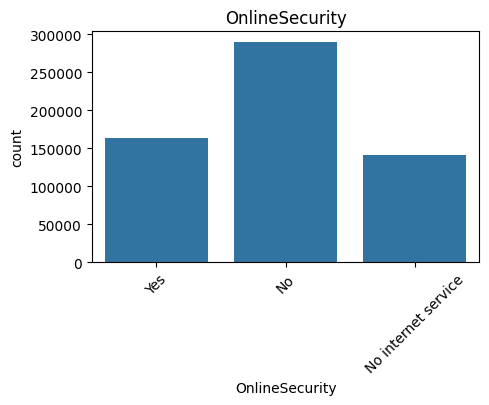

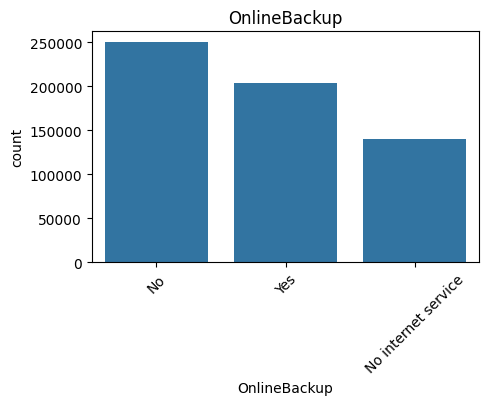

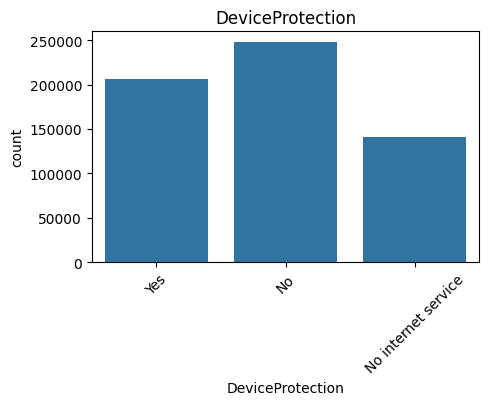

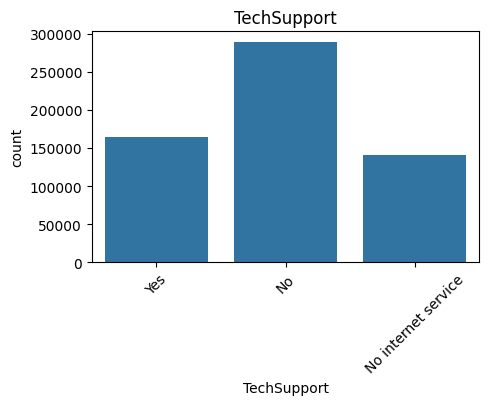

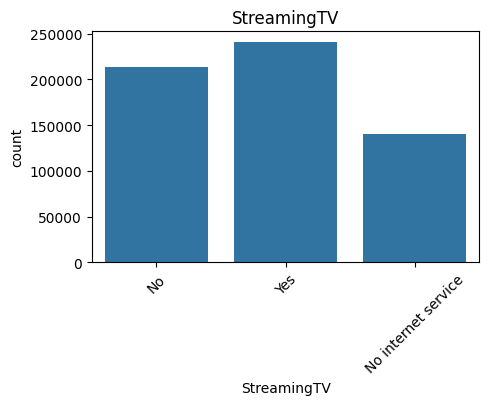

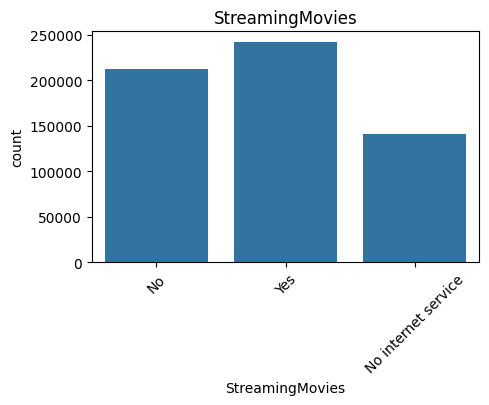

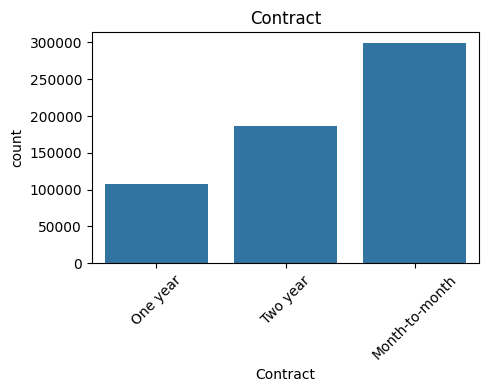

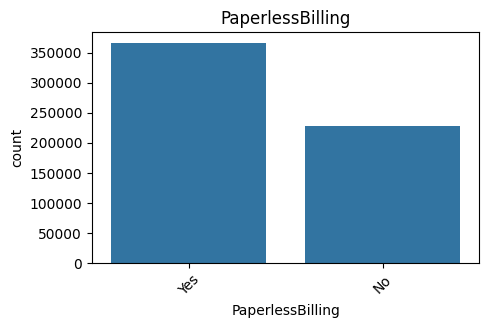

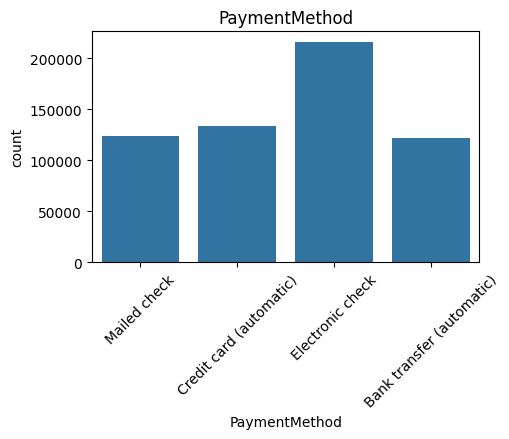

In [16]:
cat_cols = train.select_dtypes(include='object').columns
cat_cols = cat_cols.drop('Churn')

for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, data=train)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()


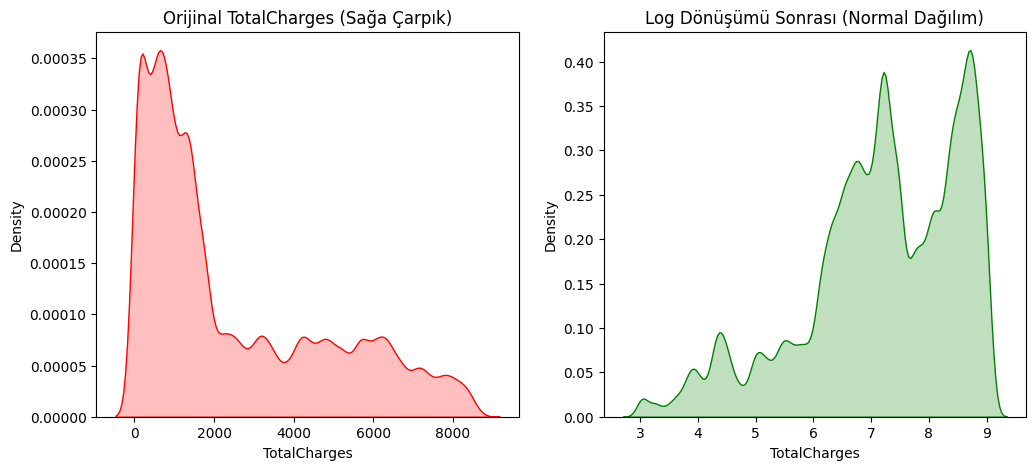

Yeni Çarpıklık Değeri: -0.79


In [17]:
# 1. Mevcut Durum (Sağa Çarpık) ve Log Dönüşümü Sonrası Yan Yana Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Orijinal Veri
sns.kdeplot(train['TotalCharges'], fill=True, ax=axes[0], color='red')
axes[0].set_title('Orijinal TotalCharges (Sağa Çarpık)')

# Log Dönüşümü (np.log1p hem 0 değerlerini korur hem de log alır)
train['TotalCharges'] = np.log1p(train['TotalCharges'])

# Dönüşüm Sonrası Veri
sns.kdeplot(train['TotalCharges'], fill=True, ax=axes[1], color='green')
axes[1].set_title('Log Dönüşümü Sonrası (Normal Dağılım)')

plt.show()

# Sayısal kontrol: Çarpıklık katsayısı (0'a ne kadar yakınsa o kadar iyi)
print(f"Yeni Çarpıklık Değeri: {train['TotalCharges'].skew():.2f}")

# Feature Engineering

In [18]:
# Müşterinin toplam aldığı hizmet sayısı
# 'Yes' olan sütunları saydırıyoruz
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
train['Total_Services'] = (train[services] == 'Yes').sum(axis=1)

In [19]:
# Oran özelliği: Aylık ücretin toplam ücrete oranı
train['Monthly_to_Total_Ratio'] = train['MonthlyCharges'] / (np.expm1(train['TotalCharges']) + 1)

# Sayısallaştırma

In [20]:
# Sözleşme tipi kritik olduğu için bunu sayısal bir "risk" puanına çevirelim
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
train['Contract_Score'] = train['Contract'].map(contract_map)

In [21]:
#Encoding: Tüm object (kategorik) sütunları sayısallaştırma
# get_dummies ile "Yes/No", "Male/Female" gibi her şeyi 0 ve 1'e çeviriyoruz
train_final = pd.get_dummies(train, drop_first=True)

In [22]:
#Gereksiz Sütunları Temizleme
train_final.drop('id', axis=1, inplace=True)

In [23]:
train_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 34 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   SeniorCitizen                          594194 non-null  int64  
 1   tenure                                 594194 non-null  int64  
 2   MonthlyCharges                         594194 non-null  float64
 3   TotalCharges                           594194 non-null  float64
 4   Total_Services                         594194 non-null  int64  
 5   Monthly_to_Total_Ratio                 594194 non-null  float64
 6   Contract_Score                         594194 non-null  int64  
 7   gender_Male                            594194 non-null  bool   
 8   Partner_Yes                            594194 non-null  bool   
 9   Dependents_Yes                         594194 non-null  bool   
 10  PhoneService_Yes                       594194 non-null  

# Model Eğitimi

In [25]:
#  Veriyi Ayırma
x= train_final.drop('Churn_Yes', axis=1)
y = train_final['Churn_Yes']

In [26]:
# Kaç kişi kalmış (0), kaç kişi gitmiş (1) görelim
print(y.value_counts())

# Çıktı şuna benzeyecek:
# False    460398  (Bunlar eski Churn=No olanlar)
# True     133796  (Bunlar eski Churn=Yes olanlar)

Churn_Yes
False    460377
True     133817
Name: count, dtype: int64


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="binary"))
        recall.append(recall_score(y_test, tahmin, average="binary"))
        f1.append(f1_score(y_test, tahmin, average="binary"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [28]:
algo_test(x,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[68541 23394]
 [ 2834 24070]]
LogisticRegression()  modeli eğitiliyor!..
[[84470  7465]
 [ 9479 17425]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[80262 11673]
 [11403 15501]]
RandomForestClassifier()  modeli eğitiliyor!..
[[84545  7390]
 [10756 16148]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[84903  7032]
 [ 9625 17279]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[83100  8835]
 [10327 16577]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[84450  7485]
 [ 9522 17382]]
MultinomialNB()  modeli eğitiliyor!..
[[70664 21271]
 [ 4058 22846]]
Eğitim tamamlandı.
En başarılı model:  GradientBoostingClassifier
Confusion Matrix:
[[84903  7032]
 [ 9625 17279]]
classification Report:
              precision    recall  f1-score   support

       False       0.90      0.92      0.91     91935
        True       0.71      0.64      0.67     26904

    accuracy                           0.86    118839
   macro avg 

,Accuracy,Precision,Recall,F1
GradientBoostingClassifier,0.859836,0.710748,0.642247,0.674763
LogisticRegression,0.857421,0.700080,0.647673,0.672858
AdaBoostClassifier,0.856890,0.698999,0.646075,0.671496
BernoulliNB,0.779298,0.507121,0.894663,0.647321
MultinomialNB,0.786863,0.517850,0.849167,0.643359
RandomForestClassifier,0.847306,0.686040,0.600208,0.640260
KNeighborsClassifier,0.838757,0.652330,0.616154,0.633726
DecisionTreeClassifier,0.805821,0.570435,0.576160,0.573283


In [32]:
from sklearn.metrics import precision_recall_curve, f1_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)

model=GradientBoostingClassifier()

#Modeli Eğitme (Öğretme)
model.fit(x_train, y_train)

# 1. Modelden olasılıkları al (en iyi model olan GradientBoosting ile)
y_scores = model.predict_proba(x_test)[:, 1]

# 2. Farklı eşik değerleri için Precision, Recall ve Eşikleri hesapla
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Her eşik için F1 skorunu hesapla
# (Precision * Recall) / (Precision + Recall) * 2
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

# 4. En yüksek F1 skorunu veren eşiği bul
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"🎯 En İyi Eşik Değeri (Best Threshold): {best_threshold:.4f}")
print(f"🚀 Bu eşik ile F1 Skoru: {best_f1:.4f}")

# 5. Yeni eşik ile final tahminleri yap
y_pred_new = (y_scores >= best_threshold).astype(int)

🎯 En İyi Eşik Değeri (Best Threshold): 0.3695
🚀 Bu eşik ile F1 Skoru: 0.7009


--- Final Model Raporu (Eşik: 0.3695) ---
              precision    recall  f1-score   support

       False       0.93      0.88      0.90     91935
        True       0.64      0.77      0.70     26904

    accuracy                           0.85    118839
   macro avg       0.79      0.82      0.80    118839
weighted avg       0.86      0.85      0.86    118839



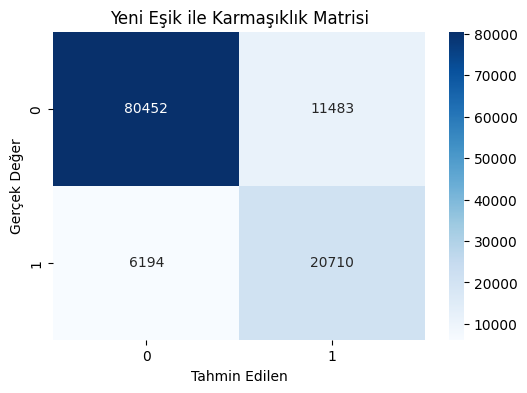

In [33]:
from sklearn.metrics import confusion_matrix, classification_report

# Yeni eşik ile raporu alalım
print("--- Final Model Raporu (Eşik: 0.3695) ---")
print(classification_report(y_test, y_pred_new))

# Karmaşıklık Matrisi Görselleştirme
cm = confusion_matrix(y_test, y_pred_new)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Yeni Eşik ile Karmaşıklık Matrisi')
plt.show()

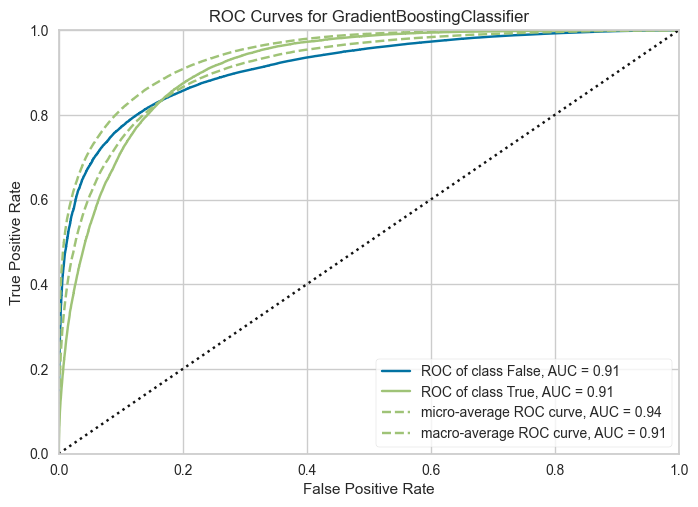

In [38]:
from yellowbrick.classifier import ROCAUC
from sklearn.model_selection import train_test_split

#model görselleştirici
visualizer = ROCAUC(model)

#Eğit ve Görselleştir
visualizer.fit(x_train, y_train)        # Eğitim verisiyle öğret
visualizer.score(x_test, y_test)        # Hiç görmediği test verisiyle puanla
visualizer.show();                       # Grafiği göster

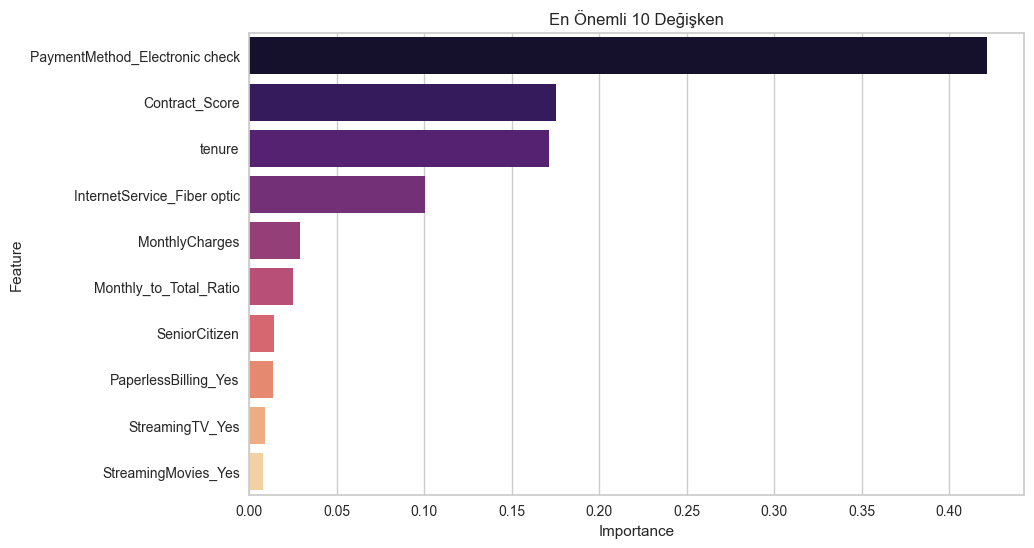

In [39]:
# Modeldeki özellik önemlerini alalım
importances = model.feature_importances_
feature_names = x.columns

# Görselleştirme
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('En Önemli 10 Değişken')
plt.show()

In [40]:
feature_importance_df

,Feature,Importance
31,PaymentMethod_Electronic check,0.421823
6,Contract_Score,0.175095
1,tenure,0.171113
13,InternetService_Fiber optic,0.100371
2,MonthlyCharges,0.029151
5,Monthly_to_Total_Ratio,0.024848
0,SeniorCitizen,0.013794
29,PaperlessBilling_Yes,0.013286
24,StreamingTV_Yes,0.008651
26,StreamingMovies_Yes,0.007832


In [53]:
import joblib

# Tüm önemli bilgileri bir sözlükte toplayalım
final_export = {
    'model': model,                  # Eğittiğin GradientBoosting modeli
    'threshold': 0.3695,             # Bulduğumuz eşik değeri
    'feature_names': list(x.columns) # Modelin beklediği sütun sırası
}

# Tek bir dosya olarak kaydedelim
joblib.dump(final_export, 'churn_project_bundle.joblib')

['churn_project_bundle.joblib']

# Test Verisi ile Tahmin

In [41]:
test_ids = test['id'] # Yarışma gönderisi için ID'leri sakla

In [42]:
# Feature Engineering (Train ile aynı sırayla)
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
test['Total_Services'] = (test[services] == 'Yes').sum(axis=1)

contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
test['Contract_Score'] = test['Contract'].map(contract_map)

In [43]:
#Log Dönüşümü (TotalCharges)
test['TotalCharges'] = np.log1p(test['TotalCharges'])

In [44]:
#Oran Özelliği
test['Monthly_to_Total_Ratio'] = test['MonthlyCharges'] / (np.expm1(test['TotalCharges']) + 1)

In [45]:
# Encoding (Sayısallaştırma)
test_final = pd.get_dummies(test, drop_first=True)

In [46]:
# Train'de olup Test'te olmayan (veya tam tersi) sütunları eşitleyelim
test_final = test_final.reindex(columns=x.columns, fill_value=0)

In [47]:
# Tahmin Yapma (En iyi eşiğin olan 0.3695'i kullanıyoruz)
# Olasılıkları alalım
test_probs = model.predict_proba(test_final)[:, 1]

In [48]:
# Belirlediğimiz eşiğe göre 0 veya 1 yapalım
test_preds = (test_probs >= 0.3695).astype(int)

In [49]:
# Sonuçları DataFrame'e dönüştür
submission = pd.DataFrame({
    'id': test_ids,
    'Churn': test_preds # 0-1 için
})

# CSV olarak kaydet
submission.to_csv('submission_final.csv', index=False)

In [55]:
submission2 = pd.DataFrame({
    'id': test_ids,
    'Churn': test_probs # Veya olasılık isteniyorsa test_probs yazabilirsin
})

# CSV olarak kaydet
submission2.to_csv('submission_final_v2.csv', index=False)

In [56]:
submission2

,id,Churn
0,594194,0.062934
1,594195,0.003903
2,594196,0.079008
3,594197,0.005294
4,594198,0.517349
...,...,...
254650,848844,0.003920
254651,848845,0.790553
254652,848846,0.252607
254653,848847,0.007229


In [51]:
# Oluşturduğumuz submission dosyasını oku
sub_check = pd.read_csv('submission_final.csv')

# Dağılıma bak
print(sub_check['Churn'].value_counts(normalize=True))

Churn
0    0.737272
1    0.262728
Name: proportion, dtype: float64


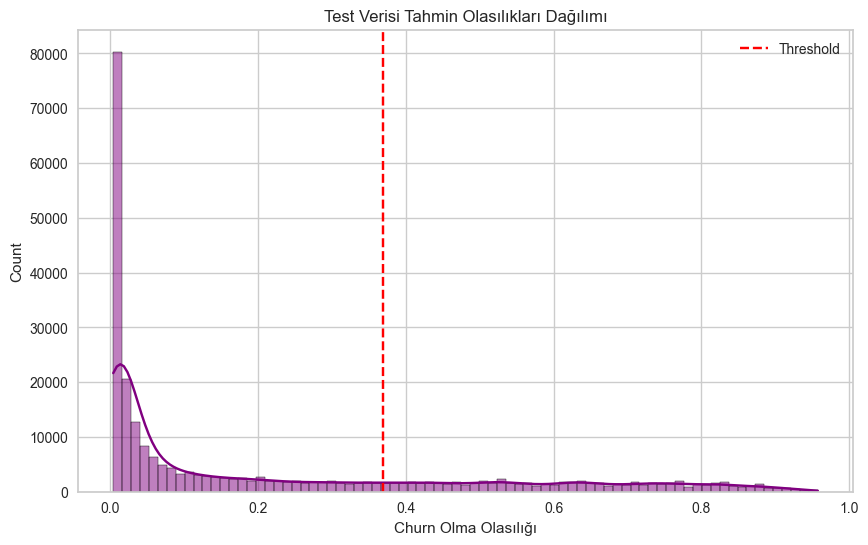

In [52]:
plt.figure(figsize=(10, 6))
sns.histplot(test_probs, kde=True, color="purple")
plt.axvline(0.3695, color='red', linestyle='--', label='Threshold')
plt.title('Test Verisi Tahmin Olasılıkları Dağılımı')
plt.xlabel('Churn Olma Olasılığı')
plt.legend()
plt.show()

# Proje Sonuç Raporu

Model: Gradient Boosting Classifier (XGBoost tabanlı).

Veri Hacmi: ~600.000 satır (Sentetik Müşteri Verisi).

Kritik Dokunuş: TotalCharges sütununa Log Dönüşümü yapılarak sağa çarpık dağılım düzeltildi ve modelin öğrenmesi kolaylaştırıldı.

Özellik Mühendisliği: Contract_Score ve Total_Services gibi yeni değişkenler türetilerek modelin ayırt edici gücü artırıldı.

Eşik (Threshold) Optimizasyonu: Varsayılan 0.5 değeri yerine 0.3695 eşiği seçilerek F1 skoru 0.67'den 0.70'e yükseltildi.

Final Başarısı: 0.91 ROC-AUC skoru ile müşterilerin %77'sini (Recall) başarıyla önceden tahmin edebilen bir yapı kuruldu.